# Siparişler

✏️ **Alıştırma**

Bugün **siparişleri** ve bunlara ait **değerlendirme puanını (review score)** inceleyeceğiz.

👉 Amacımız aşağıdaki özelliklere sahip bir DataFrame oluşturmaktır:


| özellik_adı  	| tip  	| açıklama  	|
|:---	|:---:	|:---	|
| `order_id` 	| str 	| siparişin kimliği (id) 	|
| `wait_time` 	| float 	| `order_purchase_timestamp` ile `order_delivered_customer_date` arasındaki gün sayısı 	|
| `expected_wait_time` 	| float 	| `order_purchase_timestamp` ile `estimated_delivery_date` arasındaki beklenen gün sayısı 	|
| `delay_vs_expected` 	| float 	| gerçek `order_delivered_customer_date` tahmini teslim tarihinden sonra ise iki tarih arasındaki gün sayısını döndürür, aksi halde 0 döndürür 	|
| `order_status` 	| str 	| siparişin durumu 	|
| `dim_is_five_star` 	| int 	| sipariş beş yıldız aldıysa 1, aksi halde 0 	|
| `dim_is_one_star` 	| int 	| sipariş bir yıldız aldıysa 1, aksi halde 0 	|
| `review_score` 	| int 	| 1 ile 5 arasında 	|
| `number_of_items` 	| int 	| siparişin içerdiği toplam ürün sayısı 	|
| `number_of_sellers` 	| int 	| siparişte yer alan satıcı sayısı 	|
| `price` 	| float 	| müşterinin ödediği toplam sipariş fiyatı 	|
| `freight_value` 	| float 	| müşterinin ödediği kargo ücreti 	|
| `distance_customer_seller` 	| float 	| müşteri ile satıcı arasındaki mesafe (km, isteğe bağlı) 	|  

⚠️ Ayrıca "teslim edilmemiş" siparişleri filtrelemeliyiz; aksi belirtilmedikçe bunları dahil etmeyin, çünkü potansiyel gecikmeleri hesaplayamayız.

❓ **Senin görevin**: 

- Her bir özelliği `olist/order.py` içindeki `Order` sınıfında ayrı bir metod olarak uygulayın
- Ardından, eksiksiz DataFrame'i **`NaN` içermeyecek şekilde** döndüren `get_training_data()` metodunu oluşturun.

💡 Önerilen yöntem:
- Önce aşağıdaki notebook'u kullanarak kodunuzu adım adım yazıp test edin
- Kod mantığınızdan emin olduktan sonra kodu `order.py` dosyasına kopyalayın
- Şimdilik veri işleme mantığına odaklanın; veriyi görselleştirmeyi sonraki alıştırmalarda yapacağız

🔥 Notebook için en iyi uygulamalar (okumanız zorunludur) 👇

<details>
    <summary>▸ <i>tıklayın</i></summary>

Bundan sonra keşif amaçlı notebook'lar oldukça uzun olabilir; bu nedenle aşağıdaki ilkeleri takip etmenizi şiddetle tavsiye ediyoruz:
- Kodunuzu, Notebook her zaman baştan sona çalıştırıldığında çökmeden çalışacak şekilde yazın (Run --> Run All Cells)
- Değişken adlarını dikkatli seçin
- Kısa süreyle kullanılacak ara adımlar için `tmp` veya `_` gibi geçici isimler kullanın
- Notebook boyutunu azaltmak için kodunuzu temizleyin ve hücreleri birleştirin (`Shift-M`)
- Katlanabilir başlıklar ve içerik tablosunu sıkça kullanın (bulamazsanız bir TA'ya danışın)
- Aşağıdaki kısayolları kullanın
    - `a` bir hücre üstüne ekler
    - `b` bir hücre alta ekler
    - `dd` bir hücreyi siler
    - `esc` ve `ok` tuşları ile hücreler arası gezinme
    - `Shift-Enter` hücreyi çalıştırır ve sonraki hücreye geçer
    - parantez içindeyken örn. `groupby()` üzerinde `Shift + Tab` kullanarak dokümantasyona bakabilirsiniz. Birkaç kez tekrar edin, kalıcı olarak açmak için

</details>

In [1]:
# Auto reload imported module every time a jupyter cell is executed (handy for olist.order.py updates)
%load_ext autoreload
%autoreload 2

In [2]:
# Import usual modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
%matplotlib inline

In [4]:
# Import olist data
from olist.data import Olist
olist = Olist()
data = olist.get_data()

In [5]:
# What datasets do we have access to now ?
data.keys()

dict_keys(['product_category_name_translation', 'sellers', 'orders', 'order_items', 'customers', 'order_payments', 'products', 'geolocation', 'order_reviews'])

In [6]:
orders = data['orders'].copy() # good practice to be sure not to modify your `data` variable

assert(orders.shape == (99441, 8))

## 1. `order.py` dosyasını kodlayın

### a) `get_wait_time`
    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
           `order_id`, `wait_time`, `expected_wait_time`, `delay_vs_expected`, `order_status`



🎁 Bu ilk metod için aşağıda size pseudo-kod veriyoruz 👇

> 1. `orders` DataFrame'ini inceleyin
2. DataFrame'i `teslim edilmiş (delivered)` siparişler üzerine filtreleyin
3. `datetime` ile çalışmayı düzenleyin
    - Python [`datetime`](https://docs.python.org/3/library/datetime.html) nesnelerinin ne olduğunu anlamaya zaman ayırın
    - ve tarihleri "string" tipinden `pandas.to_datetime()` kullanarak `pandas.datetime` tipine dönüştürün
4. `order_purchase_timestamp`'tan başlayarak `wait_time`'ı gün cinsinden ondalıklı bir sayı olarak hesaplayın
5. `expected_wait_time`'ı `order_purchase_timestamp`'tan başlayarak gün cinsinden hesaplayın
6. `delay_vs_expected`'i gün cinsinden hesaplayın (sipariş tahmini teslim tarihinden daha erken teslim edildiyse 0 koyun)
7. Yeni DataFrame'i kontrol edin
8. Kodunuzdan memnun kaldığınızda, notebook'tan `olist/order.py`'ye dikkatlice kopyalayabilirsiniz
9. Şimdi metodunuzu `orders.py` içinde çağırmayı deneyin
10. Kodunuz muhtemelen hemen çalışmayacaktır
11. `.py` dosyası içinde çalışacak şekilde gerekli değişiklikleri yapın

`wait_time`, `expected_wait_time` ve `delay_vs_expected`'in tam sayı değil ondalıklı gün cinsinden olmasını istiyoruz. Düşünün: 8.1 veya 8.9 günlük bir bekleme büyük fark yaratır. Bu yüzden Pandas'ın `dt.day` özelliklerini kullanmayın; çünkü bu değerleri aşağı yuvarlar.

<details>
    <summary>💡İpucu</summary>

Hem `wait_time` hem de `delay_vs_expected` için ilgili tarihler arasındaki farkı almak üzere tarihleri çıkarmanız gerekir. Ardından bu farkın kaç günü temsil ettiğini bulmak için ya [`datetime.timedelta()`](https://docs.python.org/3/library/datetime.html#timedelta-objects) ya da [`np.timedelta64()`](https://numpy.org/doc/stable/reference/arrays.datetime.html#datetime-and-timedelta-arithmetic) kullanabilirsiniz!

</details>

In [ ]:
# YOUR CODE HERE


👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [ ]:
# Test your code here
from olist.order import Order
Order().get_wait_time()

In [ ]:
from nbresult import ChallengeResult
test = Order().get_wait_time()
result = ChallengeResult('wait_time', dve_type=test["delay_vs_expected"].dtype, shape=test.shape, dve_min=test["delay_vs_expected"].min(), dve_max=test["delay_vs_expected"].max())
result.write(); print(result.check())

⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### b) `get_review_score`
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `dim_is_five_star`, `dim_is_one_star`, `review_score`

`dim_is_$N$_star` sütunu `review_score=$N$` ise `1`, değilse `0` içermelidir

<details>
    <summary markdown='span'>İpuçları</summary>

`Series.map()` veya `DataFrame.apply()` üzerine düşünün
    
</details>

👉 We load the `reviews` for you

In [ ]:
reviews = data['order_reviews'].copy()
assert(reviews.shape == (99224,7))
reviews

In [ ]:
# YOUR CODE HERE

def __init__(self):
    # Assign an attribute ".data" to all new instances of Order
    self.data = Olist().get_data()

def get_wait_time(self, is_delivered=True):
    """
    Returns a DataFrame with:
    [order_id, wait_time, expected_wait_time, delay_vs_expected, order_status]
    and filters out non-delivered orders unless specified
    """
    # Hint: Within this instance method, you have access to the instance of the class Order in the variable self, as well as all its attributes

    orders = self.data['orders'].copy()

    if is_delivered:
        orders = orders[orders['order_status'] == 'delivered']

    date_columns = [
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]



    for col in date_columns:
        orders[col] = pd.to_datetime(orders[col])

    orders['wait_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
    orders['expected_wait_time'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days
    orders['delay_vs_expected'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

    result = orders[['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected', 'order_status']]

    return result

def get_review_score(self):
    """
    Returns a DataFrame with:
    order_id, dim_is_five_star, dim_is_one_star, review_score
    """
    reviews = self.data['order_reviews'].copy()

    reviews['dim_is_five_star'] = (reviews['review_score'] == 5).astype(int)
    reviews['dim_is_one_star'] = (reviews['review_score'] == 1).astype(int)

    return reviews[['order_id', 'dim_is_five_star', 'dim_is_one_star', 'review_score']]

Yine,

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [12]:
# Test your code here
from olist.order import Order
Order().get_review_score()

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,1,0,5
99220,22ec9f0669f784db00fa86d035cf8602,1,0,5
99221,55d4004744368f5571d1f590031933e4,1,0,5
99222,7725825d039fc1f0ceb7635e3f7d9206,0,0,4


In [13]:
from nbresult import ChallengeResult
result = ChallengeResult('review_score', shape=Order().get_review_score().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_review_score.py::TestReviewScore::test_review_score PASSED          [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/review_score.pickle

git commit -m 'Completed review_score step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### c) `get_number_items`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_items` (her sipariş için toplam ürün sayısı)

In [14]:
# YOUR CODE HERE
def get_number_items(self):
    order_items = self.data['order_items'].copy()


    number_of_items = order_items.groupby('order_id')['order_item_id'].count().reset_index()

    number_of_items.columns = ['order_id', 'number_of_items']

    return number_of_items


🧪 Aynı rutin:
* DataFrame'inizi kontrol edin,
* Kodunuzu `olist/order.py` içine taşıyın
* ve gerçekten çalıştığını doğrulayın.

In [15]:
from nbresult import ChallengeResult
result = ChallengeResult('number_items',
                         shape=Order().get_number_items().shape,
                         columns=Order().get_number_items().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_number_items.py::TestNumberItems::test_column_names PASSED          [ 50%]
test_number_items.py::TestNumberItems::test_number_items PASSED          [100%]

============================== 2 passed in 0.37s ===============================


💯 You can commit your code:

git add tests/number_items.pickle

git commit -m 'Completed number_items step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### d) `get_number_sellers`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_sellers` (her sipariş için benzersiz satıcı sayısı)
        
<details>
    <summary>▸ <i>İpucu</i></summary>

`pd.Series.nunique()` metoduna bakın
</details>

In [16]:
# YOUR CODE HERE

def get_number_sellers(self):
    """
    Returns a DataFrame with:
    order_id, number_of_sellers
    """
    order_items = self.data['order_items'].copy()

    number_of_sellers = order_items.groupby('order_id')['seller_id'].nunique().reset_index()

    number_of_sellers.columns = ['order_id', 'number_of_sellers']

    return number_of_sellers

In [17]:
from nbresult import ChallengeResult
result = ChallengeResult('number_sellers',
                         shape=Order().get_number_sellers().shape,
                         columns=Order().get_number_sellers().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_number_sellers.py::TestNumberSellers::test_column_names PASSED      [ 50%]
test_number_sellers.py::TestNumberSellers::test_number_seller PASSED     [100%]

============================== 2 passed in 0.24s ===============================


💯 You can commit your code:

git add tests/number_sellers.pickle

git commit -m 'Completed number_sellers step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### e) `get_price_and_freight`
     Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `price`, `freight_value`

In [18]:
# YOUR CODE HERE

def get_price_and_freight(self):
    """
    Returns a DataFrame with:
    order_id, price, freight_value
    """

    order_items = self.data['order_items'].copy()

    price_and_freight = order_items.groupby('order_id')[['price', 'freight_value']].sum().reset_index()

    return price_and_freight

In [19]:
from nbresult import ChallengeResult
result = ChallengeResult('price', shape=Order().get_price_and_freight().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_price.py::TestPrice::test_price PASSED                              [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/price.pickle

git commit -m 'Completed price step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

## 2. Hepsini bir arada: `get_training_data`

❓ Daha önce kodladığınız metodları kullanarak `get_training_data` metodunu yazma zamanı; tüm sipariş özelliklerini tek bir tabloda toplayın.

In [ ]:
# YOUR CODE HERE

import pandas as pd
import numpy as np
from olist.utils import haversine_distance
from olist.data import Olist


class Order:
    '''
    DataFrames containing all orders as index,
    and various properties of these orders as columns
    '''
    def __init__(self):
        # Assign an attribute ".data" to all new instances of Order
        self.data = Olist().get_data()

    def get_wait_time(self, is_delivered=True):
        """
        Returns a DataFrame with:
        [order_id, wait_time, expected_wait_time, delay_vs_expected, order_status]
        and filters out non-delivered orders unless specified
        """
        # Hint: Within this instance method, you have access to the instance of the class Order in the variable self, as well as all its attributes

        orders = self.data['orders'].copy()

        if is_delivered:
            orders = orders[orders['order_status'] == 'delivered']

        date_columns = [
            'order_purchase_timestamp',
            'order_delivered_customer_date',
            'order_estimated_delivery_date'
        ]



        for col in date_columns:
            orders[col] = pd.to_datetime(orders[col])

        orders['wait_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
        orders['expected_wait_time'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days
        orders['delay_vs_expected'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.days

        result = orders[['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected', 'order_status']]

        return result

    def get_review_score(self):
        """
        Returns a DataFrame with:
        order_id, dim_is_five_star, dim_is_one_star, review_score
        """
        reviews = self.data['order_reviews'].copy()

        reviews['dim_is_five_star'] = (reviews['review_score'] == 5).astype(int)
        reviews['dim_is_one_star'] = (reviews['review_score'] == 1).astype(int)

        return reviews[['order_id', 'dim_is_five_star', 'dim_is_one_star', 'review_score']]


    def get_number_items(self):
        order_items = self.data['order_items'].copy()


        number_of_items = order_items.groupby('order_id')['order_item_id'].count().reset_index()

        number_of_items.columns = ['order_id', 'number_of_items']

        return number_of_items

    def get_number_sellers(self):
        """
        Returns a DataFrame with:
        order_id, number_of_sellers
        """
        order_items = self.data['order_items'].copy()

        number_of_sellers = order_items.groupby('order_id')['seller_id'].nunique().reset_index()

        number_of_sellers.columns = ['order_id', 'number_of_sellers']

        return number_of_sellers



    def get_price_and_freight(self):
        """
        Returns a DataFrame with:
        order_id, price, freight_value
        """

        order_items = self.data['order_items'].copy()

        price_and_freight = order_items.groupby('order_id')[['price', 'freight_value']].sum().reset_index()

        return price_and_freight

🧪 Aşağıda test edin

In [21]:
from nbresult import ChallengeResult
from olist.order import Order
data = Order().get_training_data()

result = ChallengeResult('training',
    shape=data.shape,
    columns=sorted(list(data.columns))
)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 2 items

test_training.py::TestTraining::test_training_data_columns PASSED        [ 50%]
test_training.py::TestTraining::test_training_data_shape PASSED          [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/training.pickle

git commit -m 'Completed training step'

git push origin master



💡 **Beklenen satır sayısını elde edemiyor musunuz?**
<details><summary>8 satırlık bir fark mı var?</summary>
Sonuçta `NaN` içermeyen bir DataFrame istiyoruz. `NaN`'ları kaldırmayı deneyin. (Çok karmaşık hale getirmeyin: genelde kodunuzda bir satırı değiştirmeniz yeterlidir.)
</details>
<details><summary>Başka bir fark mı var?</summary>
Belki tüm adımları tek bir DataFrame'de birleştirirken bir şey yanlış gitmiştir? Birleştirmelerinizi (merge) kontrol edin.
</details>

🏁 Tebrikler! 

💾 Notebook'unuzu ve `olist/order.py` içindeki kodunuzu commit edip pushlayın, sonra sonraki alıştırmaya geçin.

## 3. [İSTEĞE BAĞLI] `get_distance_seller_customer` 
**Bu fonksiyonu yalnızca bugünkü alıştırmaları bitirdikten sonra yazmayı deneyin.**

**Önce bir sonraki alıştırmaya geçin.**

    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `distance_seller_customer` (müşteri ile satıcı arasındaki mesafe, km cinsinden)

💡 `olist.utils` modülünde sizin için yazılmış `haversine_distance` formülüne göz atın

Bunu kullanarak `get_distance_seller_customer`'ı kodlayın.

⚠️ Bir sipariş birden fazla satıcı içerebileceği için, sipariş başına ortalama satıcı-müşteri mesafesini alın.

In [22]:
# YOUR CODE HERE
def get_distance_seller_customer(self):

    orders = self.data['orders'].copy()
    order_items = self.data['order_items'].copy()
    customers = self.data['customers'].copy()
    sellers = self.data['sellers'].copy()
    geo = self.data['geolocation'].copy()

    geo = geo.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

    orders_customers = orders.merge(customers, on = 'customer_id', how = 'inner')

    orders_customers = orders_customers.merge(
        geo,
        left_on = 'customer_zip_code_prefix',
        right_on = 'geolocation_zip_code_prefix',
        how = 'inner'
    )

    orders_customers = orders_customers.rename(columns = {
        'geolocation_lat': 'customer_lat',
        'geolocation_lng': 'customer_lng'
    })

    items_sellers = order_items.merge(sellers, on='seller_id', how='inner')

    items_sellers = items_sellers.merge(
        geo,
        left_on='seller_zip_code_prefix',
        right_on='geolocation_zip_code_prefix',
        how = 'inner'
    )

    items_sellers = items_sellers.rename(columns={
        'geolocation_lat': 'seller_lat',
        'geolocation_lng': 'seller_lng'
    })

    df = items_sellers.merge(
        orders_customers[['order_id', 'customer_lat', 'customer_lng']],
        on = 'order_id',
        how = 'inner'
    )

    df['distance_seller_customer'] = df.apply(
        lambda row: haversine_distance(
            row['seller_lng'], row['seller_lat'],
            row['customer_lng'], row['customer_lat']
        ), axis = 1
    )

    result = df.groupby('order_id')['distance_seller_customer'].mean().reset_index()

    return result

In [23]:
matching_geo = Order().get_distance_seller_customer()

👉 Hemen satıcı-müşteri mesafesinin dağılımını hızlıca inceleyelim :)

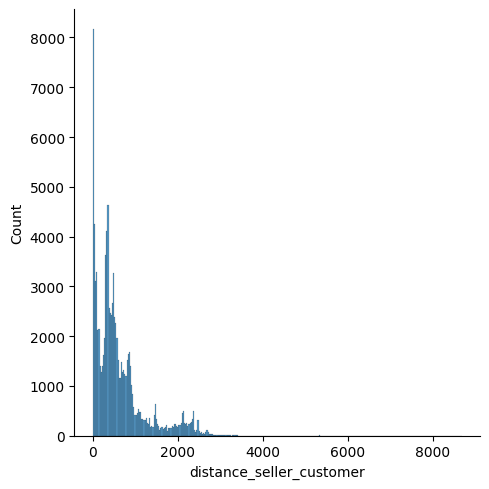

In [24]:
sns.displot(data = matching_geo, x ='distance_seller_customer')

👉 Satıcı-müşteri mesafesinin medyanı ve ortalaması nedir?

In [25]:
matching_geo['distance_seller_customer'].describe()

count    98177.000000
mean       601.685266
std        594.946172
min          0.000000
25%        187.194611
50%        433.792048
75%        798.408741
max       8677.911622
Name: distance_seller_customer, dtype: float64

👀 Yeni DataFrame'inizi kontrol edin ve kod çalıştığında `olist/order.py` içine taşıyın.

In [26]:
Order().get_distance_seller_customer()['distance_seller_customer']

0         301.504681
1         585.563937
2         312.343511
3         293.168420
4         646.163463
            ...     
98172    2754.537709
98173     351.729420
98174     339.056961
98175      72.335998
98176     134.980397
Name: distance_seller_customer, Length: 98177, dtype: float64

🧪 Kodunuzu test edin

In [27]:
from nbresult import ChallengeResult

result = ChallengeResult('distance',
    mean = Order().get_distance_seller_customer()['distance_seller_customer'].mean())
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/alihan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/alihan/code/alihantangul/data-orders
configfile: pytest.ini
plugins: dash-4.4.1, typeguard-4.4.2, anyio-4.8.0
collecting ... collected 1 item

test_distance.py::TestDistance::test_distance PASSED                     [100%]

============================== 1 passed in 0.09s ===============================


💯 You can commit your code:

git add tests/distance.pickle

git commit -m 'Completed distance step'

git push origin master



Ayrıca `with_distance_seller_customer` `True` olarak ayarlandığında `get_training_data`'yı `get_distance_seller_customer` ile birleştirecek şekilde güncelleyin.

⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!